# Match galaxies in MaNGA sample with galaxies in Illustris TNG 100-1

#### imports

In [1]:
import illustris_python as il
import matplotlib.pyplot as plt
from astropy.table import Table
import h5py
import numpy as np
import numpy.ma as ma
import tqdm
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.lines import Line2D

from scipy.optimize import linear_sum_assignment

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/')

from analyze_data import dist_cost_matrix


/Users/nityaravi/Documents/GitHub/RotationCurves/ellipticals/analyze_data.py:119: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if disp is 'median':


In [2]:
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['savefig.dpi'] = 300

In [3]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/paper_plots/IllustrisTNG/'

#### load catalogs 

In [4]:
base_path = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/'
fields = ['SubhaloFlag',  'SubhaloMassInRadType', 
          # 'SubhaloMass', 'SubhaloMassInHalfRad',
          'SubhaloVmax', 'SubhaloVmaxRad', 
          # 'SubhaloStellarPhotometricsMassInRad','SubhaloStellarPhotometricsRad', 'SubhaloHalfmassRadType', 
          # 'SubhaloSFR','SubhaloGasMetalFractions', 'SubhaloStarMetallicity'
         ]
data = il.groupcat.loadSubhalos(base_path,99,fields=fields)

In [5]:
tng_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/IllustrisTNG100-1_sfr_subhalos.fits'
sfr = Table.read(tng_fn)
sfr[:5]

SubfindID,SubhaloFlag,SubhaloVmax,SubhaloMass,SubhaloMassInRadStar,SubhaloHalfmassRadStar,SubhaloStellarPhotometricsMassInRad,SubjaloStellarPhotometricsRad,SFR_10Myr,SFR_InRadStar_10Myr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,1.0,999.3851318359375,27477.935546875,163.83421325683594,47.388057708740234,139.7124786376953,139.7124786376953,3.476639822870808,0.12875327937099296
1,1.0,514.77587890625,3666.622802734375,25.731014251708984,17.012380599975586,21.47511863708496,21.47511863708496,0.8694901463325715,0.2527390986847066
2,1.0,461.6412658691406,773.4555053710938,28.852678298950195,14.983968734741211,27.32500457763672,27.32500457763672,17.46876927916618,5.6407731425460925
3,1.0,291.9365539550781,339.1330871582031,8.159035682678223,6.530275344848633,9.197443008422852,9.197443008422852,4.9834731637805705,2.7697557128170094
4,1.0,294.4329833984375,325.36669921875,6.276475429534912,8.990845680236816,5.133338928222656,5.133338928222656,1.4813834128018435,0.3892960413055264


In [6]:
sdss_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5'

In [7]:
master_table = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v9.fits')
test_sfr = master_table['SFR'][master_table['plateifu'] == '8997-9102']
test_mstar = master_table['sphd_M_star_h'][master_table['plateifu'] == '8997-9102']

In [8]:
np.where(master_table['plateifu'] == '8997-9102')

(array([9080]),)

## sdss table

In [8]:
sdss = h5py.File(sdss_fn)

## plot galaxy mass and u - r color

In [9]:
spirals = master_table[master_table['spiral_mask'] == 1]
ellipticals = master_table[master_table['elliptical_mask']==1]

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_91963/3633621425.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4])+10,


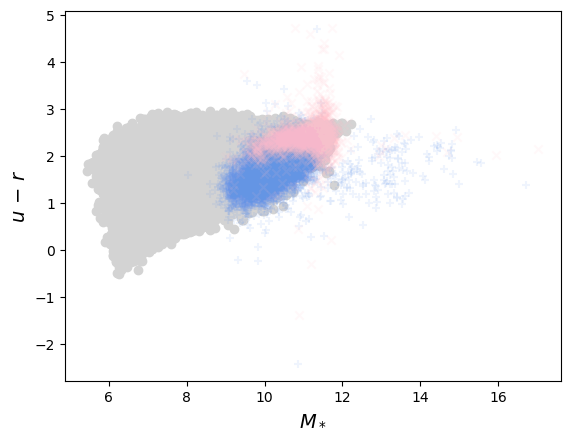

In [11]:
plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4])+10,
    sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0]
            - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0],
           marker='o', alpha =1, color='lightgrey', label='Illustris TNG 100-1'
           )

plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.scatter(spirals['sphd_M_star_h'], spirals['nsa_elpetro_absmag'][:,2] - spirals['nsa_elpetro_absmag'][:, 4],
           marker='+', color='cornflowerblue', alpha=0.1)

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['nsa_elpetro_absmag'][:,2] - ellipticals['nsa_elpetro_absmag'][:, 4],
           marker='x', color='pink', alpha=0.1)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_91963/2473881944.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4])+10,


(0.0, 4.0)

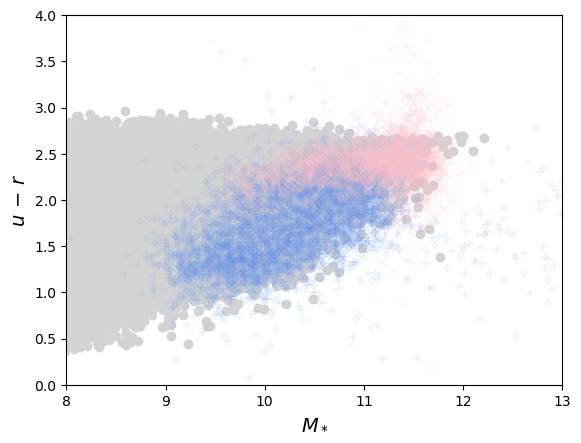

In [12]:
plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4])+10,
    sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0]
            - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0],
           marker='o', alpha =1, color='lightgrey', label='Illustris TNG 100-1'
           )

plt.xlabel(r'$M_*$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.scatter(spirals['sphd_M_star_h'], spirals['nsa_elpetro_absmag'][:,2] - spirals['nsa_elpetro_absmag'][:, 4],
           marker='+', color='cornflowerblue', alpha=0.1)

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['nsa_elpetro_absmag'][:,2] - ellipticals['nsa_elpetro_absmag'][:, 4],
           marker='x', color='pink', alpha=0.1)
plt.xlim(8,13)
plt.ylim(0,4)

## make some cuts on TNG data

1. cut all tng gals with mstar < 7. </p>
2. find min distances, save subhalo id </p>
3. cut manga sample gals where closest match > 0.5 </p>
3. recalculate distances



#### mass cut 

In [284]:
tng_u_r = sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0] - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0]
mass_cut = np.logical_and(np.logical_and(data['SubhaloFlag'], np.log10(data['SubhaloMassInRadType'][:,4]) + 10 > 7),
                         ~np.isnan(tng_u_r))

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_93868/3987983718.py:2: RuntimeWarning: divide by zero encountered in log10
  mass_cut = np.logical_and(np.logical_and(data['SubhaloFlag'], np.log10(data['SubhaloMassInRadType'][:,4]) + 10 > 7),


In [285]:
# create the new arrays

tng_u_r = tng_u_r[mass_cut]
tng_idx = sdss['subhaloIDs'][mass_cut]
tng_mstar = np.log10(data['SubhaloMassInRadType'][mass_cut,4]) + 10

In [286]:
spirals_u_r = spirals['nsa_elpetro_absmag'][:,2] - spirals['nsa_elpetro_absmag'][:, 4]
ellipticals_u_r = ellipticals['nsa_elpetro_absmag'][:,2] - ellipticals['nsa_elpetro_absmag'][:, 4]

sample_ids = np.hstack([spirals['plateifu'], ellipticals['plateifu']])
sample_spiral_mask = np.hstack([spirals['spiral_mask'], ellipticals['spiral_mask']])
sample_ellipticals_mask = np.hstack([spirals['elliptical_mask'], ellipticals['elliptical_mask']])
sample_u_r = np.hstack([spirals_u_r, ellipticals_u_r])
sample_mstar = np.hstack([spirals['sphd_M_star_h'], ellipticals['sphd_M_star_h']])



#### find min distances and save subhalo ids

In [287]:
matches = np.ones(len(sample_u_r))* np.nan # holds subhaloid
match_dist = np.ones(len(sample_u_r))* np.nan # holds distances

In [288]:
for i in tqdm.tqdm(range(len(sample_u_r))):

    dist = (sample_u_r[i] - tng_u_r)**2 + (sample_mstar[i] - tng_mstar)**2
    idx = np.argmin(dist)
    matches[i]= tng_idx[idx]
    match_dist[i] = np.sqrt(dist[idx])

100%|████████████████████████████████████| 8086/8086 [00:00<00:00, 10243.27it/s]


In [289]:
matches

array([517977.,  83315., 131050., ..., 175238., 404644.,  17186.])

#### cut matches where dist > 0.5

In [290]:
dist_cut = match_dist <= 0.5

In [291]:
sample_ids = sample_ids[dist_cut]
sample_spiral_mask = sample_spiral_mask[dist_cut]
sample_ellipticals_mask = sample_ellipticals_mask[dist_cut]
sample_u_r = sample_u_r[dist_cut]
sample_mstar = sample_mstar[dist_cut]


#### redo matches on new subsample

In [292]:
matches = np.ones(len(sample_u_r))* np.nan # holds subhaloid after dist cut
match_dist = np.ones(len(sample_u_r))* np.nan # holds distances

for i in tqdm.tqdm(range(len(sample_u_r))):

    dist = (sample_u_r[i] - tng_u_r)**2 + (sample_mstar[i] - tng_mstar)**2
    idx = np.argmin(dist)
    matches[i]= tng_idx[idx]
    match_dist[i] = np.sqrt(dist[idx])

100%|█████████████████████████████████████| 7909/7909 [00:00<00:00, 9763.31it/s]


#### now only keep unique galaxies

In [298]:
good_match = np.ones(len(sample_u_r), int) # array to hold if manga gal is kept or removed

In [299]:
# get all the unique matches
unique_tngs, counts = np.unique(matches, return_counts=True)
for i in range(len(unique_tngs)):

    subhaloid = unique_tngs[i]
    if counts[i] > 1:

        # find all manga gals associated with this sim gal
        sample_idxs = np.where(subhaloid == matches)[0]

        # check which dist is smallest
        smallest_match = np.argmin(match_dist[sample_idxs])

        for j in range(len(sample_idxs)):

            if smallest_match != j:
            
                good_match[sample_idxs[j]] = 0

#### now cut the bad manga gals

In [300]:
sample_ids = sample_ids[good_match == 1]
sample_spiral_mask = sample_spiral_mask[good_match ==1 ]
sample_ellipticals_mask = sample_ellipticals_mask[good_match ==1]
sample_u_r = sample_u_r[good_match==1]
sample_mstar = sample_mstar[good_match==1]

matches = matches[good_match==1] # array holding subhalo ids after uniqueness cuts
match_dist = match_dist[good_match==1]

In [302]:
tng_u_r_match = (sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,0,0] - sdss['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:,2,0])[np.array(matches).astype('int')] 
tng_mstar_match = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10)[np.array(matches).astype('int')] 
# match_dist = np.hypot((tng_u_r_match - sample_u_r), (tng_mstar_match-sample_mstar))

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_93868/718163953.py:2: RuntimeWarning: divide by zero encountered in log10
  tng_mstar_match = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10)[np.array(matches).astype('int')]


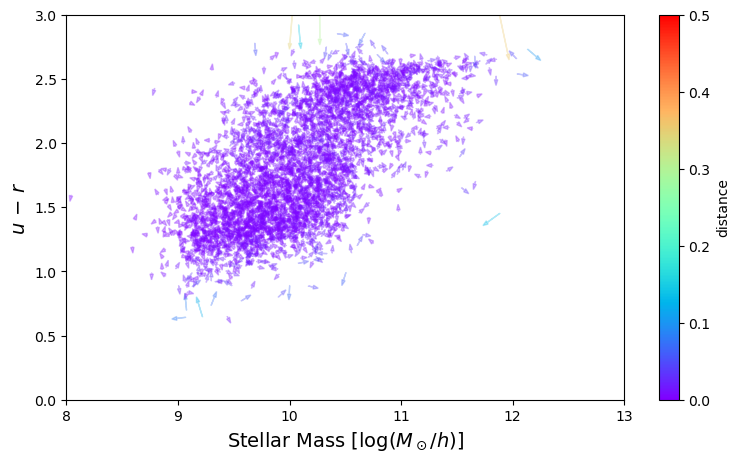

In [305]:
cmap = plt.get_cmap('rainbow')
fig,ax = plt.subplots(1,1, figsize=(9,5))
for i in range(len(sample_u_r)):

    # if match_dist[i] <= 0.5:
    plt.arrow(sample_mstar[i], sample_u_r[i], 
              tng_mstar_match[i]-sample_mstar[i], tng_u_r_match[i] - sample_u_r[i],
              alpha=0.3, color=cmap(match_dist[i]/0.5), head_width=0.03)

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.5), cmap='rainbow'),
             ax=ax, orientation='vertical', label='distance')





plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.xlim(8,13)
plt.ylim(0,3)
plt.savefig(plot_dir + 'illustris_sample_unique_match_dist.png')

#### now plot by morphology

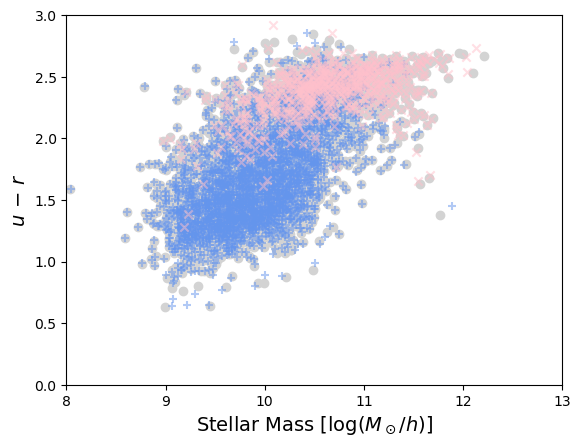

In [307]:
plt.scatter(tng_mstar_match, tng_u_r_match, marker='o', color='lightgrey')
plt.scatter(sample_mstar[sample_spiral_mask==1], sample_u_r[sample_spiral_mask==1],
            marker='+', color='cornflowerblue', alpha=0.5)
plt.scatter(sample_mstar[sample_ellipticals_mask==1], sample_u_r[sample_ellipticals_mask==1],
            marker='x', color='pink', alpha=0.5)





# cmap = plt.get_cmap('rainbow')
# fig,ax = plt.subplots(1,1, figsize=(9,5))
# for i in range(len(sample_u_r)):

#     # if match_dist[i] <= 0.5:
#     plt.arrow(sample_mstar[i], sample_u_r[i], 
#               tng_mstar_match[i]-sample_mstar[i], tng_u_r_match[i] - sample_u_r[i],
#               alpha=0.3, color=cmap(match_dist[i]/0.5), head_width=0.03)

# fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.5), cmap='rainbow'),
#              ax=ax, orientation='vertical', label='distance')





plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'$u\,-\,r$', fontsize=14)

plt.xlim(8,13)
plt.ylim(0,3)
plt.savefig(plot_dir + 'illustris_sample_unique_match.png')

### ok now: let's add matches to our master table

In [322]:
master_table['illustris_match'] = np.ones(len(master_table), int)*-999

In [323]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [334]:
for i in range(len(sample_ids)):

    gal_ID = sample_ids[i].astype(str)
    master_idx = master_table_dict[gal_ID]
    master_table['illustris_match'][master_idx] = matches[i]

In [328]:
master_table.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits')

### add other stuff to table


In [338]:
master_table['illustris_Vmax'] = np.ones(len(master_table))*-999
master_table['illustris_Mstar'] = np.ones(len(master_table))*-999

for i in range(len(master_table)):

    subhaloid =  master_table['illustris_match'][i]
    if subhaloid >= 0:

        master_table['illustris_Vmax'][i] = data['SubhaloVmax'][subhaloid]
        master_table['illustris_Mstar'][i] = np.log10(data['SubhaloMassInRadType'][subhaloid, 4]) + 10

In [342]:
master_table.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits',
                  overwrite=True)

# OLD MATCHING

## match galaxies using Mstar within 2*R50 and SFR (10 Myr)

In [6]:
# find closst match in sfr
dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/2713027700.py:2: RuntimeWarning: divide by zero encountered in log10
  dist2 = (np.log10(sfr['SubhaloMassInRadStar']) + 10 - test_mstar)**2 + (np.log10(sfr['SFR_InRadStar_10Myr']) - test_sfr)**2


In [7]:
sfr[np.argmin(dist2)]

SubfindID,SubhaloFlag,SubhaloVmax,SubhaloMass,SubhaloMassInRadStar,SubhaloHalfmassRadStar,SubhaloStellarPhotometricsMassInRad,SubjaloStellarPhotometricsRad,SFR_10Myr,SFR_InRadStar_10Myr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
501903,1.0,189.8396759033203,63.411964416503906,1.8252849578857422,3.346299171447754,1.840047836303711,1.840047836303711,2.6537609765706742,1.5716191968207742


In [8]:
test_sfr

0.192511375469816


In [9]:
test_mstar

10.2553222677357


In [10]:
np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10

10.261330674807109

In [11]:
np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)])

0.19634732493896345

In [12]:
np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]))-5

array([-4.11136432, -4.33593519, -4.21775739, ..., -4.15184317,
       -4.07122407, -4.17162604])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/3645279682.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')


Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

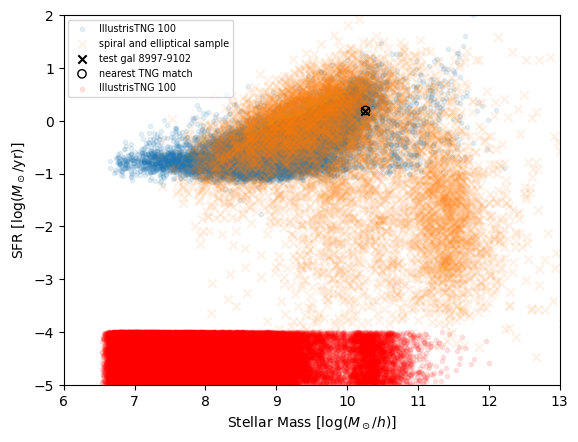

In [13]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=0.1, label='IllustrisTNG 100')
plt.scatter(master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['sphd_M_star_err_h'], 
            master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]['SFR'], marker='x', alpha=0.1,
           label='spiral and elliptical sample')
plt.scatter(master_table['sphd_M_star_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -5, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')


plt.legend(fontsize='x-small')
plt.xlim(6,13)
plt.ylim(-5,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

### SFR vs Mstar but with MaNGA sample colored by morph

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/757935654.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')


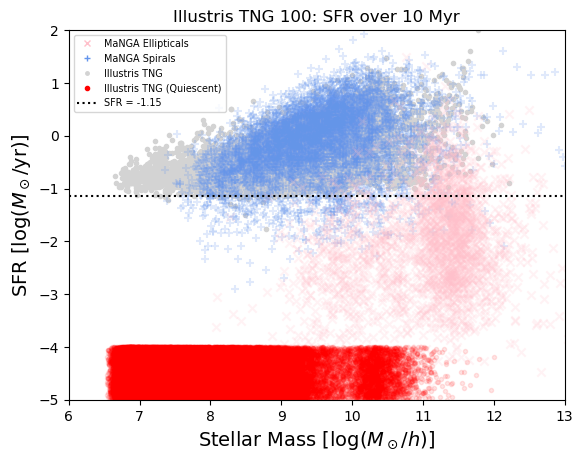

In [38]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]), marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')
plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'], marker='+', alpha=0.2,
           label='spiral sample', color='cornflowerblue')



plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'], marker='x', alpha=0.2,
           label='elliptical sample', color='pink' )
# plt.scatter(master_table['sphd_M_star_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][np.argmin(dist2)]) + 10,
#             np.log10(sfr['SFR_InRadStar_10Myr'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -5, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')



legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15')]


plt.legend(handles=legend_elements, fontsize='x-small')
plt.axhline(-1.15, color='k', linestyle=':')
plt.xlim(6,13)
plt.ylim(-5,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$', fontsize=14)

plt.title('Illustris TNG 100: SFR over 10 Myr')
plt.savefig(plot_dir + 'spiral_elliptical_SFR_10Myr.png', bbox_inches='tight')

#### remade with specific star formation rate

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/870014476.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]) - (np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10),


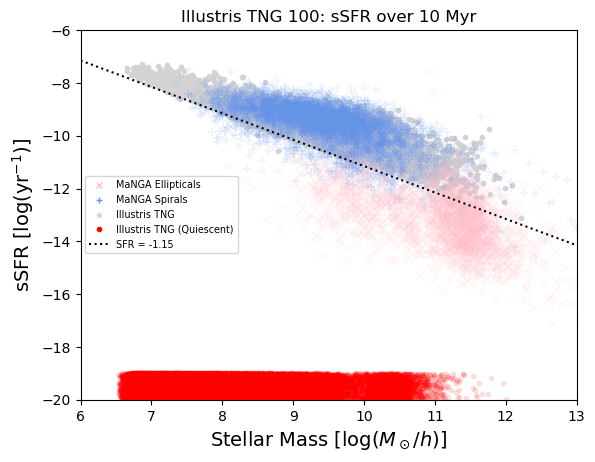

In [49]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10,
            np.log10(sfr['SFR_InRadStar_10Myr'][sfr['SubhaloFlag']!=0]) - (np.log10(sfr['SubhaloMassInRadStar'][sfr['SubhaloFlag']!=0]) + 10),
            marker='.', alpha=1, label='IllustrisTNG 100', color='lightgrey')
plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'] - master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            marker='+', alpha=0.1,
           label='spiral sample', color='cornflowerblue')



plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'] - master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'],
            marker='x', alpha=0.1,
           label='elliptical sample', color='pink' )

plt.scatter(np.log10(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0]) + 10,
            np.random.rand(len(sfr['SubhaloMassInRadStar'][sfr['SFR_InRadStar_10Myr']==0])) + -20, color='r', marker='.', alpha=0.1, label='IllustrisTNG 100')



legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15')]


plt.legend(handles=legend_elements, fontsize='x-small')
# plt.axhline(-1.15, color='k', linestyle=':')

plt.plot(np.linspace(6,13,100), -1.15 - np.linspace(6,13,100), color='k', linestyle=':')
plt.xlim(6,13)
plt.ylim(-20, -6)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'sSFR $[\log(\rm yr^{-1})]$', fontsize=14)

plt.title('Illustris TNG 100: sSFR over 10 Myr')
plt.savefig(plot_dir + 'spiral_elliptical_sSFR_10Myr.png', bbox_inches='tight')

## match galaxies using Mstar within 2*R50 and instantaneous SFR from z=0 snapshot (snapshot 99)

#### sanity check on velocity 

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/2674408995.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)


Text(0, 0.5, 'Subhalo Mass $[M_\\odot/h]$')

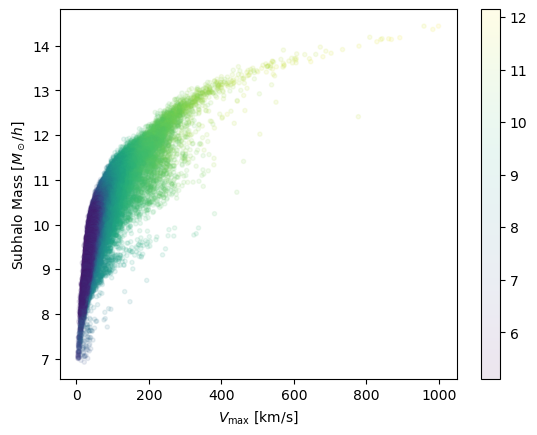

In [25]:
plt.scatter(data['SubhaloVmax'][data['SubhaloFlag']], np.log10(data['SubhaloMass'][data['SubhaloFlag']]) + 10, marker='.', alpha=0.1,
           c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) + 10)
plt.colorbar()
plt.xlabel(r'$V_{\rm max}$ [km/s]')
plt.ylabel(r'Subhalo Mass $[M_\odot/h]$')

#### check which radius is more extended

In [26]:
r50_2 = data['SubhaloHalfmassRadType'][:,4]
r207 = data['SubhaloStellarPhotometricsRad']

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/287601697.py:2: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)


Text(0, 0.5, '20.7 mag/arcsec$^2$ K-band')

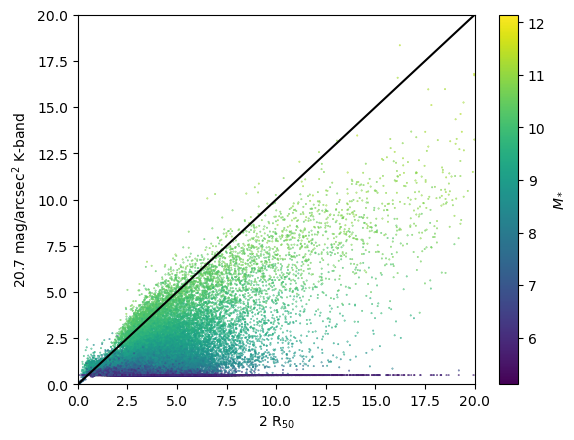

In [27]:
plt.scatter(r50_2[data['SubhaloFlag']]*2, r207[data['SubhaloFlag']], 
            c=np.log10(data['SubhaloStellarPhotometricsMassInRad'][data['SubhaloFlag']]) +  10,marker='.', s=0.5)
plt.xlim(0,20)
plt.ylim(0,20)
plt.plot([0,20],[0,20], color='k')
plt.colorbar(label=r'$M_*$')
plt.xlabel(r'2 R$_{50}$')
plt.ylabel(r'20.7 mag/arcsec$^2$ K-band')

In [69]:
dist2 = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 +\
            (np.log10(data['SubhaloSFR']) - master_table['SFR'][9080])**2

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/419658659.py:1: RuntimeWarning: divide by zero encountered in log10
  dist2 = (np.log10(data['SubhaloMassInRadType'][:,4]) + 10 - master_table['sphd_M_star_err_h'][9080])**2 +\
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/419658659.py:2: RuntimeWarning: divide by zero encountered in log10
  (np.log10(data['SubhaloSFR']) - master_table['SFR'][9080])**2


/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:3: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=1, label='IllustrisTNG 100',
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/4230633857.py:23: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,


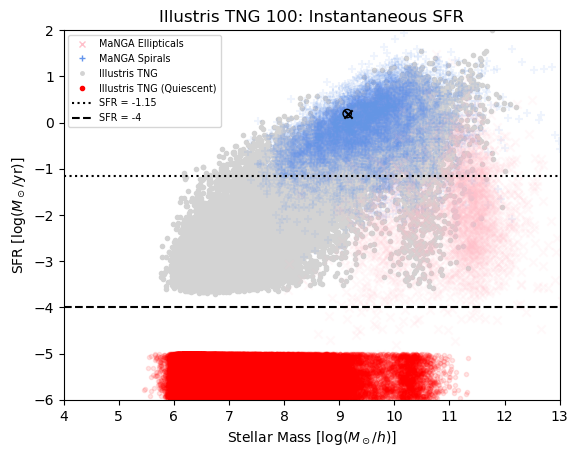

In [70]:
# first plot stellar mass vs sfr for tng gals and manga 
plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']]), marker='.', alpha=1, label='IllustrisTNG 100',
           color='lightgrey')





plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'], marker='+', alpha=0.1, color='cornflowerblue')

plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'], marker='x', alpha=0.1, color='pink')


plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

plt.scatter(np.log10(data['SubhaloMassInRadType'][np.argmin(dist2)][4]) + 10,
            np.log10(data['SubhaloSFR'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')


plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,
            np.random.rand(len(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]))-6, marker='.', color='r', alpha=0.1, label='IllustrisTNG 100 SFR=0')


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15'),
                  Line2D([0], [0], marker='none', linestyle='--', color='k', label='SFR = -4')]


plt.axhline(-1.15, linestyle=':', color='k')
plt.axhline(-4, linestyle='--', color='k')




plt.legend(handles=legend_elements, fontsize='x-small')
plt.xlim(4,13)
plt.ylim(-6,2)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$')

plt.title('Illustris TNG 100: Instantaneous SFR')
plt.savefig(plot_dir + 'spiral_elliptical_SFR_inst.png', bbox_inches='tight')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:4: RuntimeWarning: divide by zero encountered in log10
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:4: RuntimeWarning: invalid value encountered in subtract
  np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1061631465.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,


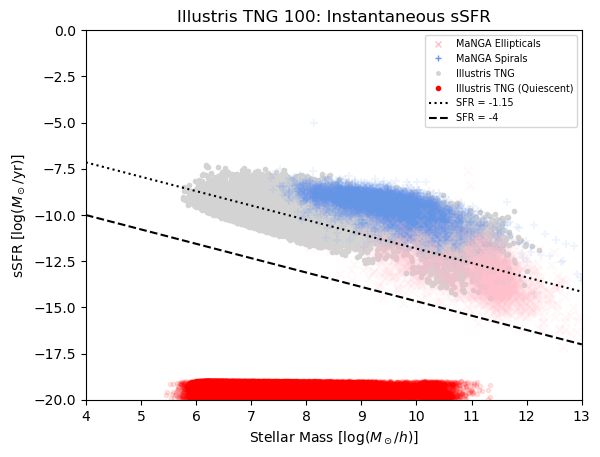

In [73]:
# first plot stellar mass vs sfr for tng gals and manga 

plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10,
            np.log10(data['SubhaloSFR'][data['SubhaloFlag']]) - (np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10), 
            marker='.', alpha=1, label='IllustrisTNG 100',
           color='lightgrey')




plt.scatter(master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['spiral_mask']==1]['SFR'] - master_table[master_table['spiral_mask']==1]['sphd_M_star_err_h'],
            marker='+', alpha=0.1, color='cornflowerblue')

plt.scatter(master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            master_table[master_table['elliptical_mask']==1]['SFR'] -master_table[master_table['elliptical_mask']==1]['sphd_M_star_err_h'], 
            marker='x', alpha=0.1, color='pink')


# plt.scatter(master_table['sphd_M_star_err_h'][9080], master_table['SFR'][9080], marker='x', color='k', label='test gal 8997-9102')

# plt.scatter(np.log10(data['SubhaloMassInHalfRadType'][np.argmin(dist2)][4]) + 10,
#             np.log10(data['SubhaloSFR'][np.argmin(dist2)]), marker='o', alpha=1, color='k', facecolor='none', label='nearest TNG match')


plt.scatter(np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]) + 10,
            np.random.rand(len(data['SubhaloMassInRadType'][:,4][data['SubhaloSFR']==0]))-20, marker='.', color='r', alpha=0.1, label='IllustrisTNG 100 SFR=0')


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=5),
                  Line2D([0], [0], marker='.', color='w', label='Illustris TNG (Quiescent)',
                          markeredgecolor='r', markerfacecolor='r', markersize=6),
                  Line2D([0], [0], marker='none', linestyle=':', color='k', label='SFR = -1.15'),
                  Line2D([0], [0], marker='none', linestyle='--', color='k', label='SFR = -4')]


# plt.axhline(-1.15, linestyle=':', color='k')
# plt.axhline(-4, linestyle='--', color='k')


plt.plot(np.linspace(4,13,100), -1.15 - np.linspace(6,13,100), color='k', linestyle=':')
plt.plot(np.linspace(4,13,100), -4 - np.linspace(6,13,100), color='k', linestyle='--')


plt.legend(handles=legend_elements, fontsize='x-small')
plt.xlim(4,13)
plt.ylim(-18,0)
plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$')
plt.ylabel(r'sSFR $[\log(M_\odot/\rm yr)]$')

plt.title('Illustris TNG 100: Instantaneous sSFR')
plt.savefig(plot_dir + 'spiral_elliptical_sSFR_inst.png', bbox_inches='tight')

### adding corresponding tng gals to master table

take the distance between each MaNGA gal and Illustris TNG gals in stellar mass-SFR plane. extract vmax, stellar mass, sfr and distance

In [88]:
#### create subsample of good tng gals
good_halo_vmax = data['SubhaloVmax'][data['SubhaloFlag']]
good_halo_mstar = np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10
good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1912976755.py:3: RuntimeWarning: divide by zero encountered in log10
  good_halo_mstar = np.log10(data['SubhaloMassInRadType'][:,4][data['SubhaloFlag']]) + 10
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_26036/1912976755.py:4: RuntimeWarning: divide by zero encountered in log10
  good_halo_sfr = np.log10(data['SubhaloSFR'][data['SubhaloFlag']])


In [89]:
master_table['TNG_Vmax'] = np.ones(len(master_table))*-999
master_table['TNG_Mstar'] = np.ones(len(master_table))*-999
master_table['TNG_SFR']= np.ones(len(master_table))*-999
master_table['TNG_distance']= np.ones(len(master_table))*-999
master_table['TNG_temp_idx']= np.ones(len(master_table))*-999

In [90]:
for i in tqdm.tqdm(range(len(master_table))):

    # check if gal in sample
    if master_table['elliptical_mask'][i] == 1 or master_table['spiral_mask'][i] == 1:

        manga_smass = master_table['sphd_M_star_h'][i]
        manga_sfr = master_table['SFR'][i]

        dists = (good_halo_mstar - manga_smass)**2 + (good_halo_sfr - manga_sfr)**2
        idx = np.argmin(dists)

        master_table['TNG_Vmax'][i] = good_halo_vmax[idx]
        master_table['TNG_Mstar'][i] = good_halo_mstar[idx]
        master_table['TNG_SFR'][i] = good_halo_sfr[idx]
        master_table['TNG_distance'][i] = np.sqrt(dists[idx])
        master_table['TNG_temp_idx'][i] = idx

  0%|                                       | 13/11273 [00:00<01:31, 123.21it/s]/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/astropy/table/column.py:1376: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value
100%|████████████████████████████████████| 11273/11273 [00:56<00:00, 199.24it/s]


In [94]:
idxs, counts = np.unique(master_table['TNG_temp_idx'], return_counts=True)
np.where(counts > 1)

(array([   0,    1,    2, ..., 3146, 3150, 3156]),)

In [93]:
sample = master_table[np.logical_or(master_table['elliptical_mask']==1, master_table['spiral_mask']==1)]

In [212]:
counts, bins = np.histogram(master_table['TNG_distance'], bins=np.linspace(0,5.2,50))
cmap = plt.get_cmap('rainbow')

In [208]:
cmap(5.2)

(1.0, 1.2246467991473532e-16, 6.123233995736766e-17, 1.0)

Text(0, 0.5, 'SFR $[\\log(M_\\odot/\\rm yr)]$')

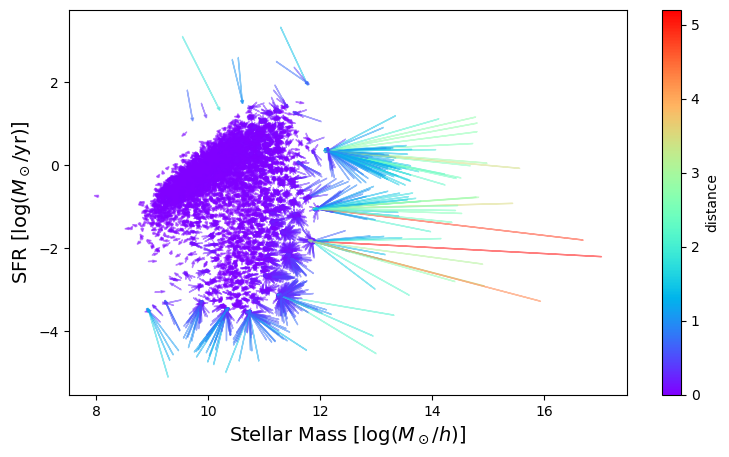

In [224]:
fig,ax = plt.subplots(1,1, figsize=(9,5))
for i in range(len(sample)):
    plt.arrow(sample['sphd_M_star_h'][i], sample['SFR'][i], 
              sample['TNG_Mstar'][i]-sample['sphd_M_star_h'][i], sample['TNG_SFR'][i]-sample['SFR'][i],
              alpha=0.5, color=cmap(sample['TNG_distance'][i]/5.2), head_width=0.05)

fig.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(0, 5.2), cmap='rainbow'),
             ax=ax, orientation='vertical', label='distance')

plt.xlabel(r'Stellar Mass $[\log(M_\odot / h)]$', fontsize=14)
plt.ylabel(r'SFR $[\log(M_\odot/\rm yr)]$', fontsize=14)

In [225]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]


In [227]:
master_table['TNG_MR90'] = np.ones(len(master_table))*-999
for i in range(len(master_table)):

    master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_25923/1614506484.py:4: RuntimeWarning: invalid value encountered in log10
  master_table['TNG_MR90'][i] = np.log10(master_table['TNG_Vmax'][i]**2 * master_table['R90_kpc'][i] / G)


(7.5, 13.0)

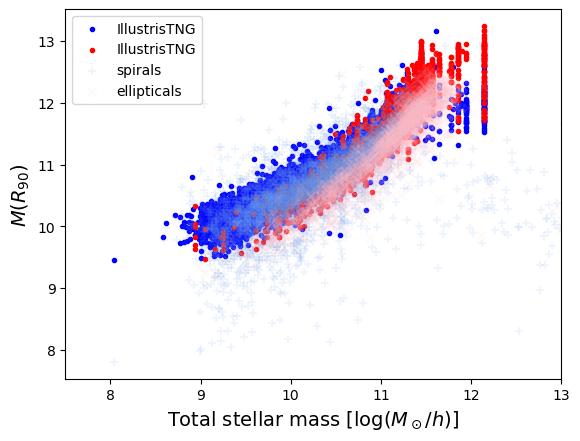

In [252]:
plt.scatter(master_table['TNG_Mstar'][master_table['spiral_mask']==1], 
            master_table['TNG_MR90'][master_table['spiral_mask']==1], alpha=1, marker='.', color='b', label='IllustrisTNG spiral match')
plt.scatter(master_table['TNG_Mstar'][master_table['elliptical_mask']==1], 
            master_table['TNG_MR90'][master_table['elliptical_mask']==1], alpha=1, marker='.', color='r', label='IllustrisTNG elliptical match')

plt.scatter(master_table['sphd_M_star_h'][master_table['spiral_mask']==1], 
            master_table['M_R90'][master_table['spiral_mask']==1], 
            alpha=0.1, marker='+', color='cornflowerblue', label='spirals')
plt.scatter(master_table['sphd_M_star_h'][master_table['elliptical_mask']==1], 
            master_table['Mvir'][master_table['elliptical_mask']==1], 
            alpha=0.1, marker='x', color='pink', label='ellipticals')
plt.xlabel(r'Total stellar mass $[\log(M_\odot/h)]$', fontsize=14)
plt.ylabel(r'$M(R_{90})$', fontsize=14)
plt.legend()
plt.xlim(7.5,13)

#### fun with assignment problems

In [1]:
mstar_tng, mstar_manga = np.meshgrid(good_halo_mstar, sample['sphd_M_star_h'])

NameError: name 'np' is not defined

## compare the two SFR measures for the same halos 

### first compare distributions of SFR, sSFR from all 3 pops

In [9]:
sfr_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/star_formation_rates.hdf5'
sfr = h5py.File(sfr_fn, 'r')

In [17]:
for name in sfr['Snapshot_99']:
    print(name)

SFR_MsunPerYrs_in_InRad_1000Myrs
SFR_MsunPerYrs_in_InRad_100Myrs
SFR_MsunPerYrs_in_InRad_10Myrs
SFR_MsunPerYrs_in_InRad_200Myrs
SFR_MsunPerYrs_in_InRad_50Myrs
SFR_MsunPerYrs_in_all_1000Myrs
SFR_MsunPerYrs_in_all_100Myrs
SFR_MsunPerYrs_in_all_10Myrs
SFR_MsunPerYrs_in_all_200Myrs
SFR_MsunPerYrs_in_all_50Myrs
SFR_MsunPerYrs_in_r30pkpc_1000Myrs
SFR_MsunPerYrs_in_r30pkpc_100Myrs
SFR_MsunPerYrs_in_r30pkpc_10Myrs
SFR_MsunPerYrs_in_r30pkpc_200Myrs
SFR_MsunPerYrs_in_r30pkpc_50Myrs
SFR_MsunPerYrs_in_r5pkpc_1000Myrs
SFR_MsunPerYrs_in_r5pkpc_100Myrs
SFR_MsunPerYrs_in_r5pkpc_10Myrs
SFR_MsunPerYrs_in_r5pkpc_200Myrs
SFR_MsunPerYrs_in_r5pkpc_50Myrs
SubfindID


In [67]:
sfr['Snapshot_99']['SubfindID']

<HDF5 dataset "SubfindID": shape (116394,), type "<i4">

In [69]:
h = il.groupcat.loadSingle(base_path, 99, subhaloID=1)

In [70]:
h

{'SubhaloBHMass': 0.12551759,
 'SubhaloBHMdot': 0.0002301299,
 'SubhaloBfldDisk': 0.90148443,
 'SubhaloBfldHalo': 0.15268138,
 'SubhaloCM': array([  124.47653, 24606.768  , 16859.104  ], dtype=float32),
 'SubhaloFlag': True,
 'SubhaloGasMetalFractions': array([7.4376333e-01, 2.4799015e-01, 8.3335524e-04, 2.9013937e-04,
        4.0014386e-03, 1.3231143e-03, 3.8415098e-04, 3.9607051e-04,
        6.9444388e-04, 3.2380351e-04], dtype=float32),
 'SubhaloGasMetalFractionsHalfRad': array([7.3769665e-01, 2.5096405e-01, 1.1245606e-03, 4.1383362e-04,
        5.3651924e-03, 1.7890783e-03, 5.1718170e-04, 5.5794109e-04,
        1.0841856e-03, 4.8734748e-04], dtype=float32),
 'SubhaloGasMetalFractionsMaxRad': array([7.5244862e-01, 2.4395068e-01, 3.7734673e-04, 1.2004986e-04,
        1.8324659e-03, 5.9897872e-04, 1.7498418e-04, 1.6359941e-04,
        2.1959751e-04, 1.1368736e-04], dtype=float32),
 'SubhaloGasMetalFractionsSfr': array([7.4573088e-01, 2.4702457e-01, 7.0538727e-04, 2.3649352e-04,
      